In [2]:
import requests
import pandas as pd

dados = pd.DataFrame.from_dict(requests.get("https://labdados.com/produtos").json())

display(dados)

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Modelagem preditiva,livros,92.45,5.609697,01/01/2020,Thiago Silva,BA,1,cartao_credito,3,-13.29,-41.71
1,Iniciando em programação,livros,43.84,0.000000,01/01/2020,Mariana Ferreira,SP,5,cartao_credito,1,-22.19,-48.79
2,Pandeiro,instrumentos musicais,87.18,2.226512,01/01/2020,Thiago Silva,RJ,4,cartao_credito,4,-22.25,-42.66
3,Corda de pular,esporte e lazer,13.65,1.257926,01/01/2020,Camila Ribeiro,RJ,4,boleto,1,-22.25,-42.66
4,Dinossauro Rex,brinquedos,28.32,2.039059,01/01/2020,Juliana Costa,RJ,1,cartao_debito,1,-22.25,-42.66
...,...,...,...,...,...,...,...,...,...,...,...,...
9430,Impressora,eletronicos,472.77,25.456706,31/12/2022,Camila Ribeiro,MT,4,cartao_credito,3,-12.64,-55.42
9431,Dashboards com Power BI,livros,54.85,3.451702,31/12/2022,Lucas Oliveira,RJ,5,cartao_credito,3,-22.25,-42.66
9432,Cubo mágico 8x8,brinquedos,19.74,0.000000,31/12/2022,Bianca Santos,RJ,5,cartao_credito,8,-22.25,-42.66
9433,Faqueiro,utilidades domesticas,52.49,0.000000,31/12/2022,Larissa Alves,DF,4,cartao_credito,5,-15.83,-47.86


### 1. Análise Descritiva
Distribuição dos valores referente a `Preço`, `Frete`, `Avalição da compra` e `Quantidade de parcelas`

In [ ]:
display(dados.info())
display(dados[["Preço","Frete","Avaliação da compra","Quantidade de parcelas"]].describe())

<class 'pandas.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 9435 non-null   str    
 1   Categoria do Produto    9435 non-null   str    
 2   Preço                   9435 non-null   float64
 3   Frete                   9435 non-null   float64
 4   Data da Compra          9435 non-null   str    
 5   Vendedor                9435 non-null   str    
 6   Local da compra         9435 non-null   str    
 7   Avaliação da compra     9435 non-null   int64  
 8   Tipo de pagamento       9435 non-null   str    
 9   Quantidade de parcelas  9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
dtypes: float64(4), int64(2), str(6)
memory usage: 1.4 MB


None

,Preço,Frete,Avaliação da compra,Quantidade de parcelas
count,9435.000000,9435.000000,9435.000000,9435.000000
mean,622.309570,33.167002,4.014520,2.927398
std,787.094508,41.973711,1.390518,2.802776
min,10.070000,0.000000,1.000000,1.000000
25%,73.610000,4.009423,3.000000,1.000000
50%,295.350000,15.648481,5.000000,1.000000
75%,884.405000,46.591030,5.000000,4.000000
max,3969.380000,216.707633,5.000000,24.000000


### 2. Análise das Categorias dos Produtos
Quantidade de produtos vendidos por categoria, categorias mais populares e preço médio por categoria

Número de produtos por categoria:


Categoria do Produto
moveis                   1886
eletronicos              1772
brinquedos               1290
eletrodomesticos         1149
esporte e lazer          1113
instrumentos musicais     753
livros                    742
utilidades domesticas     730
Name: count, dtype: int64

Média de preços por categoria:


Categoria do Produto
eletrodomesticos         1537.282010
eletronicos              1249.491941
instrumentos musicais     617.569283
moveis                    535.638388
esporte e lazer           171.280674
utilidades domesticas     105.169014
brinquedos                 76.078186
livros                     67.736846
Name: Preço, dtype: float64

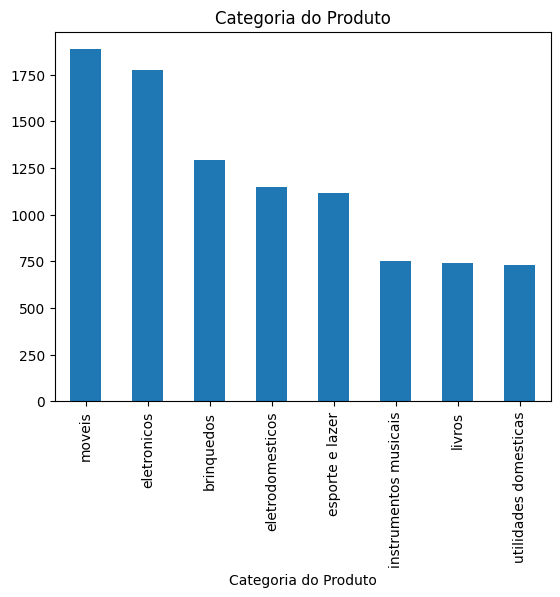

In [ ]:
print("Número de produtos por categoria:")
display(dados["Categoria do Produto"].value_counts())
dados["Categoria do Produto"].value_counts().plot(kind="bar", title="Categoria do Produto")

print("Média de preços por categoria:")
display(dados.groupby("Categoria do Produto")["Preço"].mean().sort_values(ascending=False))


### 3. Análise de Vendedores e Locais de Compra
Vendedores mais ativos, locais de compra mais comuns e desempenho das vendas por vendedor

Top 10 vendedores:


Vendedor
Thiago Silva        744
Felipe Santos       701
João Souza          694
Bruno Rodrigues     684
Bianca Santos       679
Larissa Alves       679
Juliana Costa       677
Lucas Oliveira      674
Camila Ribeiro      667
Mariana Ferreira    656
Name: count, dtype: int64

Top 10 locais de compra:


Local da compra
SP    3943
RJ    1212
MG    1102
RS     534
PR     473
SC     346
BA     310
DF     242
GO     186
PE     181
Name: count, dtype: int64

<Axes: title={'center': 'Local da compra'}, xlabel='Local da compra'>

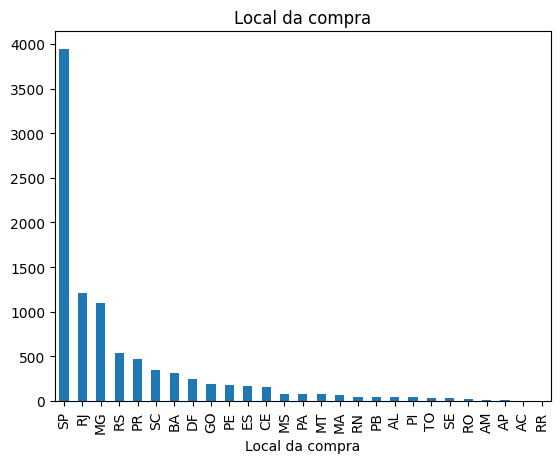

In [21]:
print("Top 10 vendedores:")
display(dados["Vendedor"].value_counts().head(10))

print("Top 10 locais de compra:")
display(dados["Local da compra"].value_counts().head(10))
dados["Local da compra"].value_counts().plot(kind="bar", title="Local da compra")

### 4. Análise de Avaliações
Distribuição das avaliações e média da avaliação por categoria

In [13]:
print('Distribuição das Avaliações:')
display(dados['Avaliação da compra'].value_counts().sort_index())

print('Média de Avaliações por Categoria:')
display(dados.groupby('Categoria do Produto')['Avaliação da compra'].mean().sort_values(ascending=False))

Distribuição das Avaliações:


Avaliação da compra
1    1199
2     343
3     830
4    1813
5    5250
Name: count, dtype: int64

Média de Avaliações por Categoria:


Categoria do Produto
brinquedos               4.070543
moveis                   4.033934
eletrodomesticos         4.014795
livros                   4.004043
instrumentos musicais    4.003984
eletronicos              3.992664
esporte e lazer          3.988320
utilidades domesticas    3.979452
Name: Avaliação da compra, dtype: float64

### 5. Análise de Produtos e Tipos de Pagamento
Produtos mais vendidos e tipos de pagamento mais comuns

Top 10 produtos mais vendidos:


Produto
Cômoda                      210
Micro-ondas                 206
Carrinho controle remoto    206
Bateria                     203
Cama king                   201
Modelagem preditiva         200
Secadora de roupas          200
Jogo de panelas             200
Blocos de montar            199
Cama box                    199
Name: count, dtype: int64

Distribuição dos tipos de pagamento:


Tipo de pagamento
cartao_credito    73.11%
boleto            20.14%
cupom              5.34%
cartao_debito      1.41%
Name: proportion, dtype: str

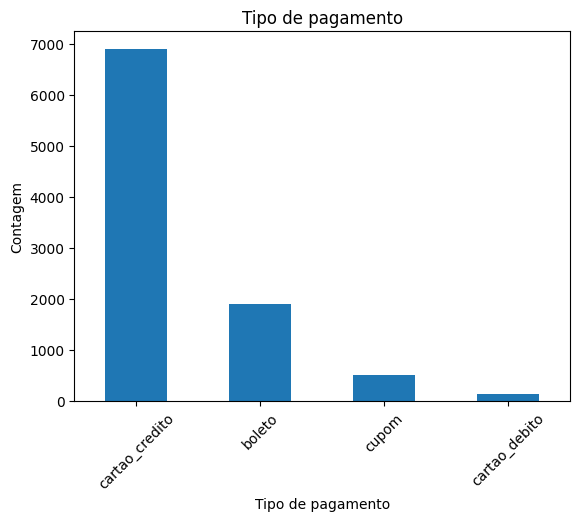

In [20]:
import matplotlib.pyplot as plt

print("Top 10 produtos mais vendidos:")
display(dados["Produto"].value_counts().head(10))

print("Distribuição dos tipos de pagamento:")
display(dados["Tipo de pagamento"].value_counts(normalize=True).map("{:.2%}".format))

dados["Tipo de pagamento"].value_counts().plot(kind="bar", title="Tipo de pagamento")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Contagem")
plt.xticks(rotation=45)
plt.show()